***Detection***

In [1]:
pip install gensim

In [2]:
import pandas as pd
import numpy as np
import re
import nltk
from nltk.tokenize import word_tokenize
from nltk.corpus import stopwords
from nltk.stem import WordNetLemmatizer
from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import CountVectorizer
from sklearn.naive_bayes import MultinomialNB
from sklearn.metrics import classification_report
import gensim.downloader as api

In [3]:
# Load GloVe embeddings
model = api.load("glove-twitter-100")



[==================================================] 100.0% 387.1/387.1MB downloaded


In [30]:
# Load data
#df = pd.read_csv("2labelpreprocessed.csv")
df = pd.read_csv("data.csv")
df['Statement'] = df['Statement'].fillna('')

In [5]:
df

,Statement,bully_or_not,Category,Severity
0,im mad hit fat bitch,bully,hate,L
1,kitchen rule booty cam rule,bully,sexist,M
2,kill self ur swap fag as bitch,bully,homophobic,H
3,say fuck u call forget cracker as,bully,homophobic,M
4,alright nice one get nothing say one fag bag,bully,homophobic,M
...,...,...,...,...
1346,leadership skill truly remarkable admire motiv...,not_bullying,NB,NB
1347,love always open learn try new thing even mean...,not_bullying,NB,NB
1348,speed adrenaline rush formula unbearable fm re...,not_bullying,NB,NB
1349,driver formula truly best athlete world trophy...,not_bullying,NB,NB


In [ ]:
columns = ['Unnamed: 0']
df.drop(columns, inplace=True, axis=1)

In [6]:
print(df['bully_or_not'].value_counts())

bully_or_not
not_bullying    677
bully           674
Name: count, dtype: int64


In [ ]:
# Split data into train and test sets
X_train, X_test, y_train, y_test = train_test_split(df['Statement'], df['bully_or_not'], test_size=0.2, random_state=42)

In [ ]:
# Vectorize text data using GloVe embeddings
vectorizer = CountVectorizer(tokenizer=lambda text: text.split())
vocabulary = vectorizer.fit_transform(X_train)
#vectorizer, vocabulary = df.CONTENT.fillna(' ')
word_index = vectorizer.vocabulary_
embedding_matrix = np.zeros((len(word_index) + 1, 100))
for word, i in word_index.items():
    if word in model:
        embedding_matrix[i] = model[word]

/usr/local/lib/python3.11/site-packages/sklearn/feature_extraction/text.py:528: UserWarning: The parameter 'token_pattern' will not be used since 'tokenizer' is not None'
  warnings.warn(


In [ ]:
# Train Naive Bayes model
nb_model = MultinomialNB()
nb_model.fit(vocabulary, y_train)

MultinomialNB()

In [ ]:
# Vectorize test data using the same vocabulary and embedding matrix
test_vocabulary = vectorizer.transform(X_test)
test_embedding_matrix = np.zeros((test_vocabulary.shape[1], 100))
for word, i in word_index.items():
    if word in model:
        test_embedding_matrix[i] = model[word]

In [ ]:
# Evaluate model
y_pred = nb_model.predict(test_vocabulary)
print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

       bully       0.87      0.97      0.91       133
not_bullying       0.97      0.85      0.91       137

    accuracy                           0.91       270
   macro avg       0.92      0.91      0.91       270
weighted avg       0.92      0.91      0.91       270



In [ ]:
y_test

289            bully
1036    not_bullying
535            bully
346            bully
1075    not_bullying
            ...     
1280    not_bullying
435            bully
722     not_bullying
54             bully
382            bully
Name: bully_or_not, Length: 270, dtype: object

In [ ]:
#Seed for reproducibility
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

import random
import torch
seed_value=42
random.seed(seed_value)
np.random.seed(seed_value)
torch.manual_seed(seed_value)
torch.cuda.manual_seed_all(seed_value)

import time

#set style for plots
sns.set_style("whitegrid")
sns.despine()
plt.style.use("seaborn-whitegrid")
plt.rc("figure", autolayout=True)
plt.rc("axes", labelweight="bold", labelsize="large", titleweight="bold", titlepad=10)

/var/folders/23/2z99b8xj5h1f_7hckmmsf0cr0000gn/T/ipykernel_16715/3519968886.py:19: MatplotlibDeprecationWarning: The seaborn styles shipped by Matplotlib are deprecated since 3.6, as they no longer correspond to the styles shipped by seaborn. However, they will remain available as 'seaborn-v0_8-<style>'. Alternatively, directly use the seaborn API instead.
  plt.style.use("seaborn-whitegrid")


<Figure size 640x480 with 0 Axes>

In [ ]:
from sklearn.metrics import confusion_matrix

In [ ]:
print(confusion_matrix(y_test, y_pred))


[[129   4]
 [ 20 117]]


In [ ]:
def conf_matrix(y, y_pred, title, labels):
    fig, ax =plt.subplots(figsize=(7.5,7.5))
    ax=sns.heatmap(confusion_matrix(y, y_pred), annot=True, cmap="Purples", fmt='g', cbar=False, annot_kws={"size":30})
    plt.title(title, fontsize=25)
    ax.xaxis.set_ticklabels(labels, fontsize=16)
    ax.yaxis.set_ticklabels(labels, fontsize=14.5)
    ax.set_ylabel('Test', fontsize=25)
    ax.set_xlabel('Predicted', fontsize=25)
    plt.show()

In [ ]:
sentiments = ["bully","not_bullying"]

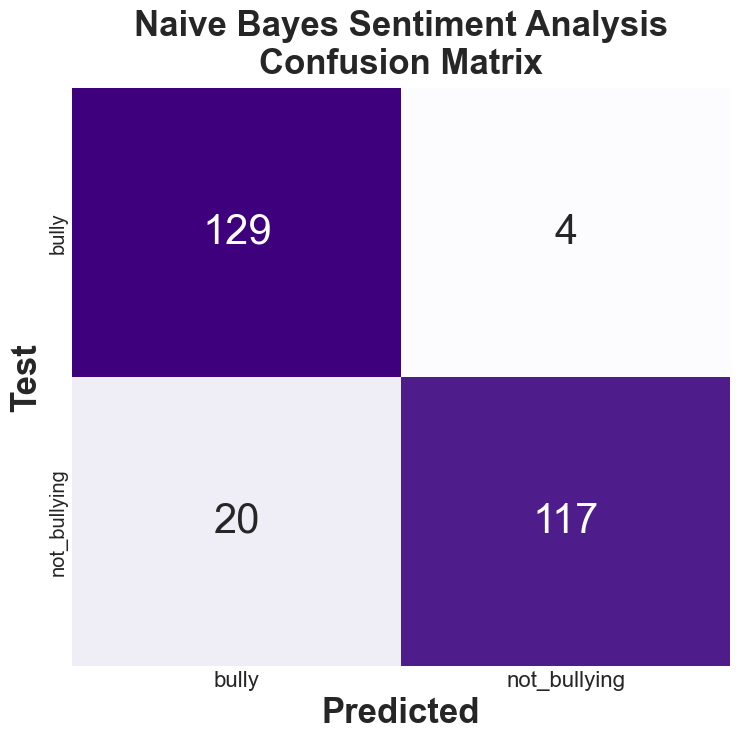

In [ ]:
conf_matrix(y_test,y_pred,'Naive Bayes Sentiment Analysis\nConfusion Matrix', sentiments)

In [ ]:
import pandas as pd
pd.set_option('display.max_colwidth', None)


In [ ]:
#TP


pred1 = np.where(y_pred=="bully")
TP_Indexes = []
for k in pred1[0]:
  if(y_test.iloc[k][0] == "b"):
      TP_Indexes.append(k)
X_test_TP = X_test.iloc[TP_Indexes]
print(X_test_TP)
X_test_TP.count()

289                                                  look like get try goddess right show ur place whore
535                                         mohammed first wife katjia wealthy sick woman islam lie stfu
346                                                                    like call top class bell end dyke
303                         gf hot take night fuck fuck well dick booty dick booty dick booty dick booty
536                                               mohammed always lie say attack others plan attack crap
                                                     ...                                                
377                                                                    smelly rag head stop move britian
629    retweet isi islam pc puzzle convert religion peace lead violence http co tbjusaemuh http co g xoh
435                       respect hateu point view oppose nature overgrowth science growth science thats
54                                                     

129

In [ ]:
#FN
pred1 = np.where(y_pred=="not_bullying")
TP_Indexes = []
for k in pred1[0]:
  if(y_test.iloc[k][0] == "b"):
      TP_Indexes.append(k)
X_test_TP = X_test.iloc[TP_Indexes]
print(X_test_TP)
X_test_TP.count()

429                      reply kardashians literally worst humanity offer reward handsomely
371    fag infact shameful humanity people like deserve abuse anticipate preach stfu preach
363                                      indigenous population low think deserve everything
513                                    homosexuality transgenders world new disaster finale
Name: Statement, dtype: object


4

In [ ]:
#TN
pred1 = np.where(y_pred=="not_bullying")
TP_Indexes = []
for k in pred1[0]:
  if(y_test.iloc[k][0] == "n"):
      TP_Indexes.append(k)
X_test_TP = X_test.iloc[TP_Indexes]
print(X_test_TP)
X_test_TP.count()

1036                                        bring much joy life xxxx thank always put smile face
1075                  every day feel like fairytale come true fairy lucky person world call mine
782                                                                remove goal laugh as laugh as
1308    proof need spend lot money incredible travel experience love share knowledge others xxxx
915                                   would look handsome man dude please heart meltin literally
                                                  ...                                           
1010                                                        gift unique special gift offer world
1115                           energy set contagious really know bring best everyone around boom
1174             philanthropic work dedication social cause admirable make real difference world
1280                       fascinate see technology transform different industry colourful combi
722                           

117

In [ ]:
#FP
pred1 = np.where(y_pred=="bully")
TP_Indexes = []
for k in pred1[0]:
  if(y_test.iloc[k][0] == "n"):
      TP_Indexes.append(k)
X_test_TP = X_test.iloc[TP_Indexes]
print(X_test_TP)
X_test_TP.count()

754                                                                                                                   jealous could get party shake head
903                                                                                                                               drug addict theif care
721                                                                                                                                 let talk mean victim
730                                                                                notice save witty reply sexists little panache want get reading level
715                                                                                   promo girl go bring next round yeah bring bring store buy capsicum
882                                                                                                                                         bos man back
847                                                                               

20

In [ ]:
from sklearn.feature_extraction.text import CountVectorizer
# create a CountVectorizer with your desired parameters
vectorizer = CountVectorizer(analyzer='word')

# fit the vectorizer to the data and extract feature names
vectorizer.fit(X_train)
feature_names = vectorizer.get_feature_names_out()


print("Feature names:")

for feature in feature_names:
    print(feature)

Feature names:
aaaaaaaaaaaaaaaah
ability
abort
aborted
abortion
absolutely
abuse
abuser
acca
accept
acceptable
accepted
access
accessible
accidentally
accolade
accomplish
accord
account
accountability
achieve
achievement
aclczn
act
active
activist
activity
actor
actress
actual
actually
adam
addictive
additional
address
adidas
admirable
admire
admit
adolf
adopt
adorably
adrenaline
adulterer
advance
advancement
adventure
advice
advise
affair
affect
affluent
affordable
afraid
africa
african
age
ago
agree
ahead
ahh
aid
aint
air
akbar
aksing
al
alain
album
alien
align
alive
allah
allahu
allot
allow
almost
alone
along
alot
already
alright
also
always
amaze
amazing
amd
amen
america
american
americans
amin
amini
among
amount
amp
anal
analysis
ancestor
angel
angelica
angry
animal
anime
aniston
anne
annoy
anotha
another
answer
ant
anticipate
antman
anybody
anyone
anything
anytime
anyway
anyways
apartheid
apple
appreciate
appreciation
approximately
arab
arabia
arabic
area
argentina
argue
argument

***Categorization***

In [ ]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score
import pandas as pd
from sklearn.feature_extraction.text import CountVectorizer
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

In [ ]:
df


,Statement,bully_or_not,Category,Severity
0,im mad hit fat bitch,bully,hate,L
1,kitchen rule booty cam rule,bully,sexist,M
2,kill urself ur swag fag as bitch,bully,homophobic,H
3,say fuck call faggot cracker as,bully,homophobic,M
4,alright nice one get nothin say one fag bag,bully,homophobic,M
...,...,...,...,...
1345,leadership skill truly remarkable admire motivate inspire team achieve goal dedication work truly impressive collabo preach harga,not_bullying,NB,NB
1346,love always open learn try new thing even mean step comfort zone willingness take risk challenge truly inspiring preach,not_bullying,NB,NB
1347,speed adrenaline rush formula unbeatable fm rello dc,not_bullying,NB,NB
1348,driver formula truly best athlete world trophy clap,not_bullying,NB,NB


In [ ]:
df= df[df.Category != 'NB']

In [ ]:
df

,Statement,bully_or_not,Category,Severity
0,im mad hit fat bitch,bully,hate,L
1,kitchen rule booty cam rule,bully,sexist,M
2,kill urself ur swag fag as bitch,bully,homophobic,H
3,say fuck call faggot cracker as,bully,homophobic,M
4,alright nice one get nothin say one fag bag,bully,homophobic,M
...,...,...,...,...
669,check many race mixed spain call hispanic blood arrogant online troll think know people possibly know sicken,bully,racist,L
670,thought another race minute,bully,racist,L
671,clueless racist like complete denial boy fact kill race race card mention race longer behind sick bastard pull trigger,bully,racist,M
672,respectfully think wrong alain genetic physiological trait determine race far fetched notion psychological intelligence trait iq future time orientation delay gratification also genetically predetermine let cut horseshit th century wasp civilization art literature science asian civilization art literature science negroid primitive tribal culture still live mud hut write language,bully,racist,L


In [ ]:

df.dropna(inplace=True)

/var/folders/23/2z99b8xj5h1f_7hckmmsf0cr0000gn/T/ipykernel_16715/1001247032.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df.dropna(inplace=True)


In [ ]:
df

,Statement,bully_or_not,Category,Severity
0,im mad hit fat bitch,bully,hate,L
1,kitchen rule booty cam rule,bully,sexist,M
2,kill urself ur swag fag as bitch,bully,homophobic,H
3,say fuck call faggot cracker as,bully,homophobic,M
4,alright nice one get nothin say one fag bag,bully,homophobic,M
...,...,...,...,...
669,check many race mixed spain call hispanic blood arrogant online troll think know people possibly know sicken,bully,racist,L
670,thought another race minute,bully,racist,L
671,clueless racist like complete denial boy fact kill race race card mention race longer behind sick bastard pull trigger,bully,racist,M
672,respectfully think wrong alain genetic physiological trait determine race far fetched notion psychological intelligence trait iq future time orientation delay gratification also genetically predetermine let cut horseshit th century wasp civilization art literature science asian civilization art literature science negroid primitive tribal culture still live mud hut write language,bully,racist,L


In [ ]:
X = df['Statement']
y = df['Category']

In [ ]:
X

0                                                                                                                                                                                                                                                                                                                                                                               im mad hit fat bitch
1                                                                                                                                                                                                                                                                                                                                                                        kitchen rule booty cam rule
2                                                                                                                                                                                                                             

In [ ]:
X = pd.DataFrame(X)

In [ ]:
from imblearn.over_sampling import SMOTE
from sklearn.model_selection import train_test_split

In [ ]:
from sklearn.preprocessing import LabelEncoder

In [ ]:
le = LabelEncoder()
X_encoded = X.copy()
for col in X_encoded.columns:
    if X_encoded[col].dtype == 'object':
        X_encoded[col] = le.fit_transform(X_encoded[col])

In [ ]:
smote = SMOTE(random_state=42)
X_resampled, y_resampled = smote.fit_resample(X_encoded, y)

In [ ]:
X_resampled

,Statement
0,262
1,284
2,279
3,502
4,8
...,...
870,331
871,622
872,429
873,292


In [ ]:
y_resampled

0            hate
1          sexist
2      homophobic
3      homophobic
4      homophobic
          ...    
870        sexist
871        sexist
872        sexist
873        sexist
874        sexist
Name: Category, Length: 875, dtype: object

In [ ]:
type(X_resampled)

pandas.core.frame.DataFrame

In [ ]:
(unique, counts) = np.unique(y_resampled, return_counts=True)
np.asarray((unique, counts)).T

array([['hate', 175],
       ['homophobic', 175],
       ['racist', 175],
       ['religious', 175],
       ['sexist', 175]], dtype=object)

In [ ]:
X_resampled_df = pd.DataFrame(X_resampled, columns=X_encoded.columns)

In [ ]:
from sklearn.pipeline import Pipeline
from sklearn.metrics import classification_report

In [ ]:
X_train, X_test, y_train, y_test = train_test_split(X_resampled_df, y_resampled, test_size=0.1, random_state=42,stratify=y_resampled)

In [ ]:
# create a CountVectorizer with your desired parameters
vectorizer = CountVectorizer(analyzer='word')

# fit the vectorizer to the data and extract feature names
vectorizer.fit(X_resampled_df)
feature_names = vectorizer.get_feature_names_out()

# create a RandomForestClassifier with your desired parameters
rfc = RandomForestClassifier()

# create a pipeline that includes the vectorizer and classifier
pipeline = Pipeline([
    ('vectorizer', vectorizer),
    ('classifier', rfc)
])
X_resampled_df=X_resampled_df['Statement']
# fit the pipeline to your data
pipeline.fit(X_resampled_df.values.astype('U'), y_resampled)

score = pipeline.score(X_test['Statement'].values.astype('U'), y_test)
print("Accuracy:", score)


Accuracy: 0.8863636363636364


In [ ]:
from sklearn.metrics import classification_report

# make predictions on your test data using your trained pipeline
y_pred = pipeline.predict(X_test['Statement'].astype('U'))

# generate the classification report
class_report = classification_report(y_test, y_pred)

# print the classification report
print(class_report)

              precision    recall  f1-score   support

        hate       0.88      0.83      0.86        18
  homophobic       0.88      0.82      0.85        17
      racist       0.76      0.89      0.82        18
   religious       0.95      1.00      0.97        18
      sexist       1.00      0.88      0.94        17

    accuracy                           0.89        88
   macro avg       0.89      0.89      0.89        88
weighted avg       0.89      0.89      0.89        88



***Severity***

In [31]:
from sklearn.svm import SVC
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, classification_report
import pandas as pd
from sklearn.feature_extraction.text import CountVectorizer
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
from imblearn.over_sampling import SMOTE
from sklearn.preprocessing import LabelEncoder
from sklearn.pipeline import Pipeline

In [32]:
df

,Statement,Severity
0,im mad hit fat bitch,L
1,kitchen rule booty cam rule,M
2,kill urself ur swag fag as bitch,H
3,say fuck call faggot cracker as,M
4,alright nice one get nothin say one fag bag,M
...,...,...
669,check many race mixed spain call hispanic bloo...,L
670,thought another race minute,L
671,clueless racist like complete denial boy fact ...,M
672,respectfully think wrong alain genetic physiol...,L


In [33]:
X = df['Statement']
y = df['Severity']

In [34]:
X

,Statement
0,im mad hit fat bitch
1,kitchen rule booty cam rule
2,kill urself ur swag fag as bitch
3,say fuck call faggot cracker as
4,alright nice one get nothin say one fag bag
...,...
669,check many race mixed spain call hispanic bloo...
670,thought another race minute
671,clueless racist like complete denial boy fact ...
672,respectfully think wrong alain genetic physiol...


In [35]:
y

,Severity
0,L
1,M
2,H
3,M
4,M
...,...
669,L
670,L
671,M
672,L


In [36]:
df['Severity'].fillna('L', inplace=True) #by default fill with L value

In [37]:
df.Severity.unique()

array(['L', 'M', 'H'], dtype=object)

In [38]:
df.Severity.value_counts()

,count
Severity,
M,300
L,243
H,131


In [39]:
df

,Statement,Severity
0,im mad hit fat bitch,L
1,kitchen rule booty cam rule,M
2,kill urself ur swag fag as bitch,H
3,say fuck call faggot cracker as,M
4,alright nice one get nothin say one fag bag,M
...,...,...
669,check many race mixed spain call hispanic bloo...,L
670,thought another race minute,L
671,clueless racist like complete denial boy fact ...,M
672,respectfully think wrong alain genetic physiol...,L


In [40]:
X= pd.DataFrame(X)

In [41]:
le = LabelEncoder()
X_encoded = X.copy()
for col in X_encoded.columns:
    if X_encoded[col].dtype == 'object':
        X_encoded[col] = le.fit_transform(X_encoded[col])

In [42]:
smote = SMOTE(random_state=42)
X_resampled, y_resampled = smote.fit_resample(X_encoded, y)

In [43]:
X_resampled_df = pd.DataFrame(X_resampled, columns=X_encoded.columns)

In [44]:
# split the resampled data into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(X_resampled_df, y_resampled, test_size=0.2, random_state=42,stratify=y_resampled)

In [45]:
# create a CountVectorizer with your desired parameters
vectorizer = CountVectorizer(analyzer='word')

In [46]:
# fit the vectorizer to the training data and extract feature names
vectorizer.fit(X_resampled_df)
#feature_names = vectorizer.get_feature_names()

CountVectorizer()

In [47]:
svm = SVC()#support vector classifier

In [48]:
# create a pipeline that includes the vectorizer and classifier
pipeline = Pipeline([
    ('vectorizer', vectorizer),
    ('classifier', svm)
])

In [49]:
X_resampled_df=X_resampled_df['Statement']

In [50]:
pipeline.fit(X_resampled_df.values.astype('U'), y_resampled)

Pipeline(steps=[('vectorizer', CountVectorizer()), ('classifier', SVC())])

In [52]:
# evaluate the performance of the pipeline on the testing data
score = pipeline.score(X_test['Statement'].values.astype('U'), y_test)
#score = accuracy_score(y_test, y_pred)
print("Accuracy:", score)

Accuracy: 0.8611111111111112


In [53]:
from sklearn.metrics import classification_report

# make predictions on your test data using your trained pipeline
y_pred = pipeline.predict(X_test['Statement'].astype('U'))

# generate the classification report
class_report = classification_report(y_test, y_pred)

# print the classification report
print(class_report)

              precision    recall  f1-score   support

           H       0.95      0.67      0.78        60
           L       0.80      0.95      0.87        60
           M       0.87      0.97      0.91        60

    accuracy                           0.86       180
   macro avg       0.87      0.86      0.86       180
weighted avg       0.87      0.86      0.86       180



In [57]:
def conf_matrix(y, y_pred, title, labels):
    fig, ax =plt.subplots(figsize=(7.5,7.5))
    ax=sns.heatmap(confusion_matrix(y, y_pred), annot=True, cmap="Purples", fmt='g', cbar=False, annot_kws={"size":30})
    plt.title(title, fontsize=25)
    ax.xaxis.set_ticklabels(labels, fontsize=16)
    ax.yaxis.set_ticklabels(labels, fontsize=14.5)
    ax.set_ylabel('Test', fontsize=25)
    ax.set_xlabel('Predicted', fontsize=25)
    plt.show()

In [58]:
from sklearn.metrics import confusion_matrix

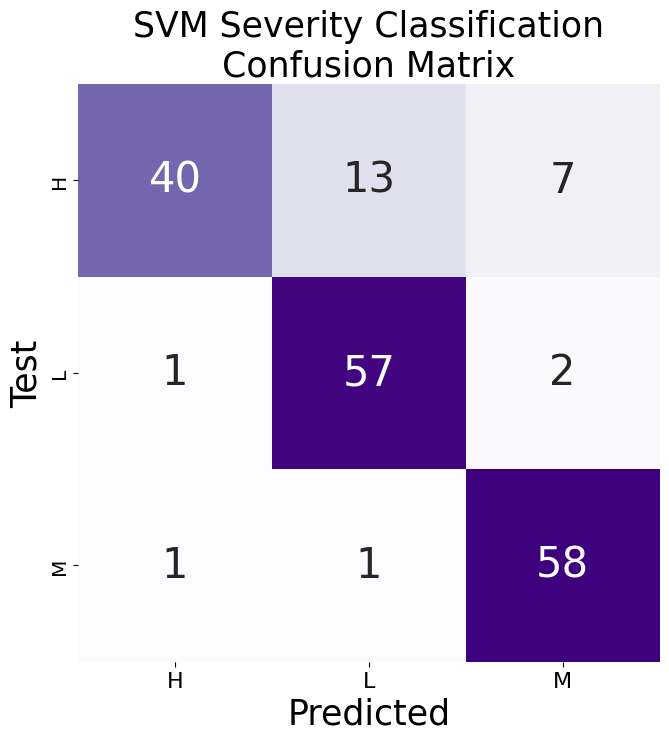

In [59]:
# prompt: I want to print a heatmap same as detection def conf_matrix(y, y_pred, title, labels):
#     fig, ax =plt.subplots(figsize=(7.5,7.5))
#     ax=sns.heatmap(confusion_matrix(y, y_pred), annot=True, cmap="Purples", fmt='g', cbar=False, annot_kws={"size":30})
#     plt.title(title, fontsize=25)
#     ax.xaxis.set_ticklabels(labels, fontsize=16)
#     ax.yaxis.set_ticklabels(labels, fontsize=14.5)
#     ax.set_ylabel('Test', fontsize=25)
#     ax.set_xlabel('Predicted', fontsize=25)
#     plt.show()

def conf_matrix_severity(y, y_pred, title, labels):
    fig, ax =plt.subplots(figsize=(7.5,7.5))
    ax=sns.heatmap(confusion_matrix(y, y_pred), annot=True, cmap="Purples", fmt='g', cbar=False, annot_kws={"size":30})
    plt.title(title, fontsize=25)
    ax.xaxis.set_ticklabels(labels, fontsize=16)
    ax.yaxis.set_ticklabels(labels, fontsize=14.5)
    ax.set_ylabel('Test', fontsize=25)
    ax.set_xlabel('Predicted', fontsize=25)
    plt.show()

# Now call this function with the appropriate variables from the Severity section
severity_labels = ['H', 'L', 'M'] # Assuming these are your severity labels
conf_matrix_severity(y_test, y_pred, 'SVM Severity Classification\nConfusion Matrix', severity_labels)